# 第9章 MountainCar／Acrobot：報酬がまれにしか得られない環境

CartPole では、でたらめに動いても、棒が倒れるまでの回数はエピソードごとに違い（第0章で seed 0〜99 を測ったところ 9〜93 回）、報酬の合計にも差が出ました。この章の **MountainCar** と **Acrobot** は、どちらも「ゴールに着くまで、1ステップごとに報酬 -1」の環境です。ゴールに着かないうちは、どう動いても同じ報酬しか得られません。このような、報酬の違いがまれにしか現れない環境で、**探索** がどれだけ難しくなるかを、測った数字で見ます。

まず、でたらめな行動で、2つの環境のゴールに着く回数を数えます。次に、Stable-Baselines3（SB3）の DQN を RL Zoo の調整済みの値で学習させ、MountainCar を解きます。そのあと、表形式の Q 学習のサンプル（NumPy）で、報酬に手を加えてゴールへ導く **報酬設計**（reward shaping）を試します。最後に、Acrobot も DQN で解きます。

- **前提**: [第7章 CartPole（DQN）](../ch07_cartpole_dqn/ch07_cartpole_dqn.ipynb)を終えていること（DQN と `EvalCallback` の使い方は第7章と同じです）。表形式の Q 学習は[第4章](../ch04_cliffwalking/ch04_cliffwalking.ipynb)で扱いました
- **所要の目安**: 実行は CPU で 15 分ほど（著者の環境で、Notebook 全体を上から実行して約 8 分）
- **使う装置**: CPU で十分です（この章では GPU を使いません）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、Stable-Baselines3 2.9.0、PyTorch 2.14.1）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。学習にかかる時間は、パソコンによって変わります。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. 報酬がまれにしか得られない環境で、でたらめな探索ではゴールに着きにくいことを、測った回数で説明できる
2. SB3 の DQN を RL Zoo の調整済みのハイパーパラメータで学習させ、MountainCar と Acrobot を解いて、成績と動く様子を見られる
3. 表形式の Q 学習のサンプルで、報酬設計（ポテンシャルに基づく形）を加える行がどこかを示し、加えたときと加えないときの違いを、測った値で説明できる

完了条件は、この Notebook を上から最後まで実行して、4節の DQN が残した「一番よい時点のモデル」が、MountainCar-v0 の 100 回の評価で報酬の合計の平均 **-110 以上** になることです。-110 は、Gymnasium が MountainCar-v0 を「解けた」とみなす目安（`reward_threshold`）です。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | 測る：でたらめな行動で探索の難しさを見る | ゴールに着いた回数、台車の位置 |
| 4節 | 動かして楽しむ：SB3 の DQN で MountainCar | 成績、山を登る様子、学習中の評価 |
| 5節 | 読む・比べる：表形式の Q 学習と報酬設計（NumPy のサンプル） | 初めてゴールしたエピソード、ゴールした回数 |
| 6節 | 動かして楽しむ：SB3 の DQN で Acrobot | 成績、振り上げる様子 |
| 7節 | 遊んでみる | 試してみる設定 |

DQN は、概要資料の[強化学習の手法の地図](../../overview/rl.md)で「ニューラルネットワークで近似する」領域の、方策オフの手法です（第7章）。表形式の Q 学習は「表で覚える」領域の手法です（第4章）。報酬設計は、手法ではなく、環境の報酬に手を加える工夫なので、どちらの手法とも組み合わせられます。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う関数を用意します。

In [1]:
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor

torch.set_num_threads(1)  # 計算に使うスレッドを1つにする（著者が seed を変えて測ったときの条件とそろえるため）

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


# 環境 env_id で、方策 policy（観測 → 行動の番号を返す関数）で episodes 回遊ばせ、報酬の合計の平均と標準偏差を返す
def evaluate(env_id, policy, episodes=100, seed=100):
    env = gym.make(env_id)
    totals = np.zeros(episodes)
    for i in range(episodes):
        observation, info = env.reset(seed=seed if i == 0 else None)
        while True:
            observation, reward, terminated, truncated, info = env.step(policy(observation))
            totals[i] += reward
            if terminated or truncated:
                break
    return totals.mean(), totals.std()


# 環境 env_id で、方策 policy で1エピソード遊ばせ、every ステップごとの (ステップ数, 絵) の一覧を返す（絵は Gymnasium の描画）
def record_episode(env_id, policy, seed, every):
    env = gym.make(env_id, render_mode="rgb_array")
    observation, info = env.reset(seed=seed)
    shots = [(0, env.render())]
    steps = 0
    while True:
        observation, reward, terminated, truncated, info = env.step(policy(observation))
        steps += 1
        if steps % every == 0 or terminated or truncated:
            shots.append((steps, env.render()))
        if terminated or truncated:
            return shots


# SB3 のモデルで、決まった行動（一番よいと見積もった行動）を選ぶ方策を返す
def sb3_policy(model):
    return lambda observation: int(model.predict(observation, deterministic=True)[0])

関数の説明:

- `evaluate` と `record_episode` は、第7章の関数に、環境の名前 `env_id` を渡す引数を足したものです。`evaluate` は、最初の `reset` にだけ `seed=100` を渡すので、どの方策も、同じ始まり方の 100 回で比べられます。`record_episode` は、`every` ステップごとの絵（Gymnasium の描画）を集めます
- `sb3_policy` は、SB3 のモデルを、観測を受け取って行動の番号を返す関数にします（第7章では、同じことを `lambda` で毎回書いていました）

## 3. 測る：でたらめな行動で探索の難しさを見る

### 3-1. 2つの環境

**MountainCar-v0** は、谷底にいる台車を、右の山の上の旗（位置 0.5）まで登らせる環境です。

- 観測: 台車の位置（-1.2〜0.6）と速度（-0.07〜0.07）の2つの小数
- 行動: 0 が左へ加速、1 が加速しない、2 が右へ加速
- 報酬: 1ステップごとに -1。旗に着くと終わり（`terminated`）、200 ステップで打ち切り（`truncated`）
- 台車のエンジンは弱く、右へ加速し続けるだけでは坂を登りきれません（7節）。いったん左の坂を登って勢いをつけると、登れます（4節の GIF）

**Acrobot-v1** は、2本の棒をつないだ振り子の、つなぎ目の関節だけを回して、先端を決まった高さより上に振り上げる環境です。

- 観測: 2つの関節の角度の cos と sin（4つ）と、2つの関節の角速度（2つ）の、6つの小数
- 行動: 0 が関節を -1 の力で回す、1 が回さない、2 が +1 の力で回す
- 報酬: 1ステップごとに -1（先端が高さの線を越えたステップだけ 0）。越えると終わり（`terminated`）、500 ステップで打ち切り（`truncated`）

どちらも、ゴールに着くまでは、何をしても 1ステップごとに -1 です。報酬の合計は、ゴールに早く着くほど大きくなり、着かなければ打ち切りまでのステップ数 × -1（MountainCar は -200、Acrobot は -500）です。Gymnasium の「解けた」の目安は、MountainCar-v0 が -110、Acrobot-v1 が -100 です（Gymnasium 1.3.0 の環境の登録）。

### 3-2. でたらめな行動で 100 回ずつ遊ぶ

でたらめな行動で、それぞれ 100 回遊ばせ、ゴールに着いた回数を数えます。MountainCar では、各エピソードで台車が一番右まで行った位置も記録します。

MountainCar-v0: 100 回のうちゴールに着いた回数 0、エピソードの長さの平均 200.0
  台車が一番右まで行った位置: 平均 -0.395、100 回の中の最大 -0.188（旗は 0.5）


Acrobot-v1: 100 回のうちゴールに着いた回数 1、エピソードの長さの平均 499.3


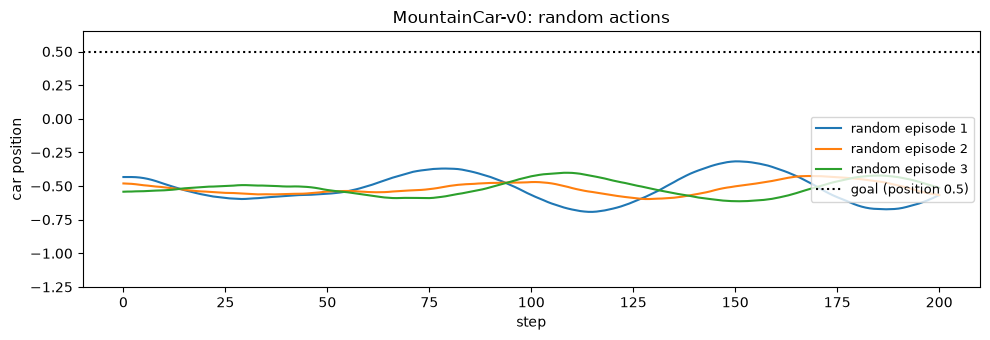

In [2]:
random_positions = []  # MountainCar の最初の 3 エピソードの、台車の位置の移り変わり（図に使う）
for env_id in ["MountainCar-v0", "Acrobot-v1"]:
    env = gym.make(env_id)
    env.action_space.seed(0)
    goals, lengths, max_positions = 0, [], []
    for i in range(100):
        observation, info = env.reset(seed=100 if i == 0 else None)
        positions = [observation[0]]
        while True:
            observation, reward, terminated, truncated, info = env.step(env.action_space.sample())
            positions.append(observation[0])
            if terminated or truncated:
                break
        goals += terminated
        lengths.append(len(positions) - 1)
        if env_id == "MountainCar-v0":
            max_positions.append(max(positions))
            if i < 3:
                random_positions.append(positions)
    print(f"{env_id}: 100 回のうちゴールに着いた回数 {goals}、エピソードの長さの平均 {np.mean(lengths):.1f}")
    if env_id == "MountainCar-v0":
        print(f"  台車が一番右まで行った位置: 平均 {np.mean(max_positions):.3f}、100 回の中の最大 {max(max_positions):.3f}（旗は 0.5）")

fig, ax = plt.subplots(figsize=(10, 3.5))
for k, positions in enumerate(random_positions):
    ax.plot(positions, label=f"random episode {k + 1}")
ax.axhline(0.5, color="black", linestyle=":", label="goal (position 0.5)")
ax.set_xlabel("step")
ax.set_ylabel("car position")
ax.set_ylim(-1.25, 0.65)
ax.set_title("MountainCar-v0: random actions")
ax.legend(loc="center right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "ch09_random.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: MountainCar では、100 回のうち旗に着いた回数は 0 で、どのエピソードも打ち切りの 200 ステップまで続きました。台車が一番右まで行った位置は、平均 -0.395、100 回の中で一番右でも -0.188 で、旗の 0.5 には遠く届いていません。Acrobot では、100 回のうち 1 回だけ、先端が線を越えました（エピソードの長さの平均は 499.3 で、ほかの 99 回は打ち切りの 500 ステップまで続いたことが分かります）。

図は、MountainCar の最初の 3 エピソードの、台車の位置の移り変わりです。どのエピソードも、谷底（位置 -0.5 あたり）の近くを、およそ -0.7〜-0.3 の範囲で行ったり来たりしているだけで、黒い点線の旗（0.5）には近づいていません。

MountainCar では、でたらめに動くと、ゴールに着かないので、どのエピソードも報酬の合計が -200 になります。どの行動を選んでも結果が同じなので、どの行動がよかったかを、報酬から区別できません。第4章の Q 学習のように、報酬の違いから Q 値を学ぶ手法は、ゴールに着く経験を一度もしないうちは、手がかりがありません。これが「報酬がまれにしか得られない環境」での探索の難しさです。

## 4. 動かして楽しむ：SB3 の DQN で MountainCar

### 4-1. 学習させる

SB3 の `DQN` で MountainCar を学習させます。ハイパーパラメータは、第7章と同じく **RL Zoo** の、MountainCar-v0 用の値（コメントは「Tuned」）を使います（出典は末尾）。第7章の CartPole 用の値と比べると、学習率が大きく（0.004。第7章は 0.0023）、γ が小さく（0.98。第7章は 0.99）、ε の最後の値が大きく（0.07。第7章は 0.04）、学習のステップ数は 120,000 です（第7章は 50,000）。

第7章と同じく、`EvalCallback` で、2,500 ステップごとに評価し、それまでで一番成績のよい時点のモデルを `checkpoints` フォルダに保存します。1回の評価で遊ばせる回数は、第7章の 10 回から **20 回** に増やしました（理由は4-2節）。著者の環境では 290 秒ほどかかりました。

In [3]:
# RL Zoo（v2.9.0）の DQN の MountainCar-v0 用のハイパーパラメータ（出典は末尾）
MC_PARAMS = dict(
    learning_rate=4e-3, batch_size=128, buffer_size=10_000, learning_starts=1000, gamma=0.98,
    target_update_interval=600, train_freq=16, gradient_steps=8,
    exploration_fraction=0.2, exploration_final_eps=0.07, policy_kwargs=dict(net_arch=[256, 256]),
)

mc_train_env = Monitor(gym.make("MountainCar-v0"))
mc_model = DQN("MlpPolicy", mc_train_env, seed=0, device="cpu", tensorboard_log="logs", **MC_PARAMS)
# 2,500 ステップごとに 20 回遊ばせて評価し、それまでで一番よい時点のモデルと、評価の記録を checkpoints/ に保存する
mc_callback = EvalCallback(make_vec_env("MountainCar-v0", n_envs=1, seed=200), n_eval_episodes=20, eval_freq=2500,
                           best_model_save_path="checkpoints/dqn_mountaincar", log_path="checkpoints/dqn_mountaincar",
                           verbose=0)

start = time.perf_counter()
mc_model.learn(total_timesteps=120_000, callback=mc_callback, tb_log_name="dqn_mountaincar")
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
mc_episode_rewards = np.array(mc_train_env.get_episode_rewards())
print("学習中のエピソードの数:", len(mc_episode_rewards))
print("学習中にゴールに着いたエピソードの数:", int(np.sum(mc_episode_rewards > -200)))
mc_evals = np.mean(mc_callback.evaluations_results, axis=1)
print("2,500 ステップごとの評価（20 回の平均）:", np.round(mc_evals, 1))

学習にかかった時間: 289 秒
学習中のエピソードの数: 698
学習中にゴールに着いたエピソードの数: 338
2,500 ステップごとの評価（20 回の平均）: [-200.  -200.  -200.  -200.  -200.  -200.  -200.  -200.  -200.  -200.
 -200.  -200.  -200.  -200.  -200.  -200.  -200.  -200.  -200.  -200.
 -200.  -200.  -200.  -200.  -200.  -167.  -150.5 -156.  -139.2 -200.
 -177.6 -200.  -200.  -189.4 -156.2 -175.  -129.  -177.6 -200.  -109.6
 -104.6 -100.6 -116.  -112.7 -111.6 -105.4 -106.4 -116.8]


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 289 秒でした（パソコンによって変わります）。120,000 ステップの間に、エピソードは 698 回あり、そのうち 338 回で旗に着きました。2,500 ステップごとの評価（20 回の平均）は、2,500〜62,500 ステップの 25 回がすべて -200.0 で、評価では一度も旗に着いていません。65,000 ステップで初めて -167.0 になり、そこから 97,500 ステップまでは -129.0〜-200.0 を行ったり来たりしています。100,000 ステップから最後の 120,000 ステップまでは -100.6〜-116.8 で、一番よかったのは 105,000 ステップの -100.6 です。

`seed=0`（学習）と `seed=200`（学習中の評価の環境）を固定しています。`checkpoints` フォルダと `logs` フォルダは、学習のたびに作り直せるものなので、Git の管理から外しています。学習の記録を TensorBoard で見る手順は、[第1章](../ch01_first_training/ch01_first_training.ipynb)の6-2節と同じです（フォルダを `chapters\ch09_mountaincar_acrobot\logs` にします）。

### 4-2. 成績を測る

最後の時点のモデルと、一番よい時点のモデルを、それぞれ 100 回評価します。

In [4]:
mc_best = DQN.load("checkpoints/dqn_mountaincar/best_model", device="cpu")
for name, m in [("最後の時点のモデル", mc_model), ("一番よい時点のモデル", mc_best)]:
    mean, std = evaluate("MountainCar-v0", sb3_policy(m))
    print(f"{name}: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

最後の時点のモデル: 報酬の合計の平均 -111.7、標準偏差 20.7


一番よい時点のモデル: 報酬の合計の平均 -99.7、標準偏差 11.6


**期待する結果**（上の出力の読み方）: 最後の時点（120,000 ステップ）のモデルは平均 -111.7（標準偏差 20.7）で、-110 にわずかに届いていません。一番よい時点のモデル（4-1節の評価が -100.6 だった 105,000 ステップの時点）は平均 -99.7（標準偏差 11.6）で、この章の完了条件（-110 以上）を満たしています。

著者が学習の seed を 0〜4 に変えて測った値は、次のとおりです（このセルと同じ評価の方法）。

| モデル | seed 0〜4 の平均 | -110 以上だった seed |
|---|---|---|
| 一番よい時点 | -98.6〜-100.1 | 5 つすべて |
| 最後の時点 | -105.1〜-147.1 | seed 3 だけ（-105.1） |

4-1節の評価の回数を、第7章と同じ 10 回にして seed 0〜4 で測ったときは、一番よい時点のモデルは -98.6〜-129.2 で、seed 2 だけが -129.2 と、-110 に届きませんでした。seed 2 で保存されたのは、10 回の平均が -95.7 だった時点ですが、100 回で測り直すと -129.2 でした。10 回の評価では、たまたま成績のよかった時点を「一番よい時点」として選んでしまうことがあるので、この章では 20 回に増やしました。評価は学習とは別の環境で行うので、最後の時点のモデルの成績は、10 回のときと 20 回のときで、どの seed でも同じでした。

SB3 の DQN の既定値のまま（RL Zoo の値を渡さずに）同じ 120,000 ステップ学習させた場合も、著者が seed 0〜4 で測りました。一番よい時点のモデルは、seed 0 が -155.3、seed 1〜4 が -200.0（100 回とも旗に着かない）で、最後の時点のモデルは、どの seed でも -200.0 でした。既定値と RL Zoo の値は、学習率・リプレイバッファの大きさ・ネットワークの大きさ・ε の下げ方など、多くの点で違うので、どの違いが効いたのかは確かめていません。

### 4-3. 山を登る様子を見る

一番よい時点のモデルで1エピソード遊ばせ、3 ステップごとの絵を GIF に保存します。

ゴールまでのステップ数: 101


GIF の枚数: 35


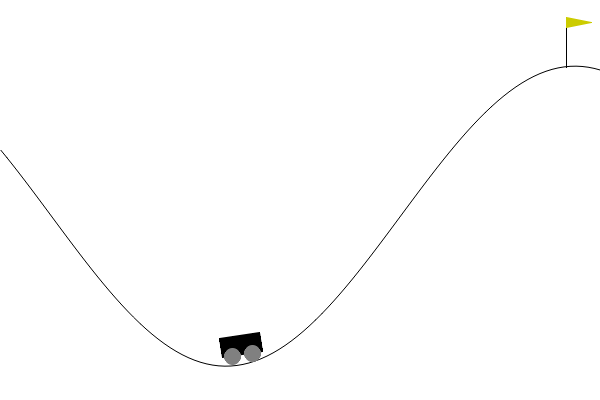

In [5]:
shots = record_episode("MountainCar-v0", sb3_policy(mc_best), seed=0, every=3)
print("ゴールまでのステップ数:", shots[-1][0])
imageio.v3.imwrite(FIGURES / "ch09_mountaincar.gif", [frame for _, frame in shots], duration=100, loop=0)
print("GIF の枚数:", len(shots))
Image(filename=FIGURES / "ch09_mountaincar.gif")

**期待する結果**（上の出力の読み方）: 一番よい時点のモデルは、`seed=0` で始めたこのエピソードで、101 ステップで旗に着きました。GIF には、最初の絵と 3 ステップごとの絵 33 枚と、旗に着いたときの絵の、合わせて 35 枚を書き込みます。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、4-3節の GIF です。台車は、はじめに少し右へ動いたあと、左の坂を高くまで登り、そこから坂を下りながら勢いをつけて、右の坂を一気に登って旗に着きます。

1 枚を 100 ミリ秒で表示します。MountainCar の描画は 1 秒に 30 ステップ（Gymnasium の `render_fps`）なので、3 ステップごとの絵を 100 ミリ秒ずつ見せると、ほぼその速さです。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 に第0章で、public にした後の 2026-10-10 に第3〜5章で確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じエピソードのコマ送りの図を作ります。

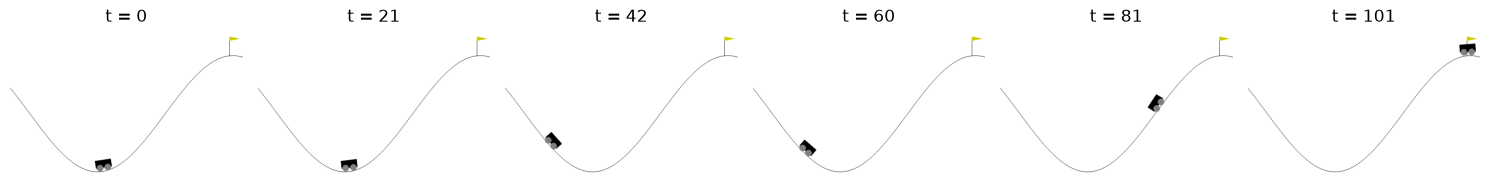

In [6]:
picks = np.linspace(0, len(shots) - 1, 6).round().astype(int)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.6))
for ax, i in zip(axes, picks):
    t, frame = shots[i]
    ax.imshow(frame)
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "ch09_mountaincar_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 4-3節のエピソードから、等間隔に選んだ 6 枚（t = 0、21、42、60、81、101）です。t = 0 と 21 では谷底の近くにいた台車が、t = 42 と 60 では左の坂の高いところにいます。t = 81 では右の坂の途中にいて、t = 101 で旗の位置に着いています。

## 5. 読む・比べる：表形式の Q 学習と報酬設計

### 5-1. サンプルを動かす

4節の DQN は、RL Zoo の調整済みの値のおかげで、ゴールにたどり着けました。ここでは別の方法として、**報酬そのものに手を加えて、ゴールへの手がかりを増やす** 報酬設計を試します。分かりやすいように、第4章の表形式の Q 学習を使います。台車の位置と速度を、それぞれ 20 の区間に分けて、20 × 20 のマス目の表にします（第7章の3節で、CartPole の観測を区切ったのと同じ考え方です）。

報酬設計の係数 `shaping` を 0（報酬設計なし）と 100,000（あり）にして、同じ 1,000 エピソードずつ学習させます。著者の環境では、合わせて 10 秒ほどかかりました。

学習にかかった時間（2通りの合計）: 9 秒
設定          初めて旗に着いたエピソード   旗に着いた回数（1,000 回のうち）   学習後の表の評価（100 回の平均）


no shaping                  465                         32                         -175.3


shaping                       5                        808                         -152.1


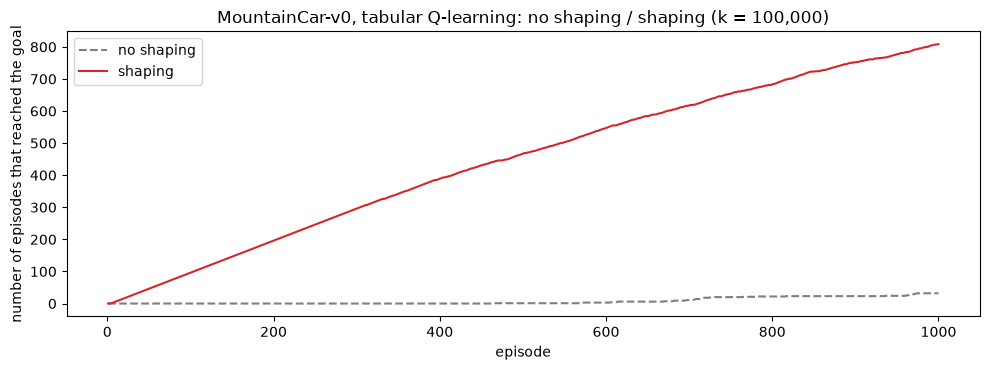

In [7]:
N_BINS = 20  # 位置と速度を、それぞれ何区間に分けるか


# MountainCar の観測（位置, 速度）を、表のマス目の番号 (位置の区間, 速度の区間) に直す
def discretize(observation):
    position = int((observation[0] + 1.2) / 1.8 * N_BINS)
    velocity = int((observation[1] + 0.07) / 0.14 * N_BINS)
    return min(position, N_BINS - 1), min(velocity, N_BINS - 1)


# ポテンシャル Φ(観測)：台車の「速さの分」と「坂の高さの分」を足したもの（5-2節）に、係数 k を掛ける
def potential(observation, k):
    position, velocity = observation
    return k * (0.5 * velocity**2 + 0.0025 / 3 * np.sin(3 * position))


# 表形式の Q 学習（第4章と同じ更新）で MountainCar を episodes 回学習させる。shaping=0 で報酬設計なし
# Q の表と、エピソードごとの長さと、エピソードごとに旗に着いたか（True/False）の一覧を返す
def q_learning(episodes=1000, shaping=0.0, alpha=0.1, gamma=0.99, epsilon=0.1, seed=0):
    env = gym.make("MountainCar-v0")
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_BINS, N_BINS, 3))
    lengths, reached = [], []
    observation, info = env.reset(seed=seed)
    for episode in range(episodes):
        state, steps = discretize(observation), 0
        while True:
            # ε-greedy で行動を選ぶ（ε は一定）
            action = rng.integers(3) if rng.random() < epsilon else int(np.argmax(Q[state]))
            next_observation, reward, terminated, truncated, info = env.step(action)
            next_state = discretize(next_observation)
            steps += 1
            # 報酬設計：環境の報酬に F = γ × Φ(次の観測) - Φ(今の観測) を足す（旗に着いたら次の Φ は 0 とする）
            if shaping:
                next_potential = 0.0 if terminated else potential(next_observation, shaping)
                reward += gamma * next_potential - potential(observation, shaping)
            # Q 学習の更新（打ち切りのときは、次の観測の Q 値を使って続きを見積もる）
            target = reward if terminated else reward + gamma * Q[next_state].max()
            Q[state][action] += alpha * (target - Q[state][action])
            observation, state = next_observation, next_state
            if terminated or truncated:
                break
        lengths.append(steps)
        reached.append(terminated)
        observation, info = env.reset()
    return Q, np.array(lengths), np.array(reached)


def table_policy(Q):
    return lambda observation: int(np.argmax(Q[discretize(observation)]))


tables = {}
start = time.perf_counter()
for name, k in [("no shaping", 0.0), ("shaping", 100_000.0)]:
    tables[name] = q_learning(shaping=k)
print(f"学習にかかった時間（2通りの合計）: {time.perf_counter() - start:.0f} 秒")

print("設定          初めて旗に着いたエピソード   旗に着いた回数（1,000 回のうち）   学習後の表の評価（100 回の平均）")
for name, (Q, lengths, reached) in tables.items():
    first = int(np.argmax(reached)) + 1 if reached.any() else None
    mean, _ = evaluate("MountainCar-v0", table_policy(Q))
    print(f"{name:12s} {str(first):>18s} {int(reached.sum()):26d} {mean:30.1f}")

fig, ax = plt.subplots(figsize=(10, 3.8))
styles = {"no shaping": ("tab:gray", "--"), "shaping": ("tab:red", "-")}
for name, (_, _, reached) in tables.items():
    color, linestyle = styles[name]
    ax.plot(np.arange(1, len(reached) + 1), np.cumsum(reached), color=color, linestyle=linestyle, label=name)
ax.set_xlabel("episode")
ax.set_ylabel("number of episodes that reached the goal")
ax.set_title("MountainCar-v0, tabular Q-learning: no shaping / shaping (k = 100,000)")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "ch09_shaping.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 2通りの学習は、合わせて 9 秒でした。報酬設計なし（`no shaping`）では、初めて旗に着いたのは 465 回目のエピソードで、1,000 回のうち旗に着いたのは 32 回です。報酬設計あり（`shaping`）では、5 回目で初めて旗に着き、1,000 回のうち 808 回で旗に着きました。学習後の表で 100 回評価すると（環境がくれる報酬だけで測ります）、なしが -175.3、ありが -152.1 です。どちらも、Gymnasium の目安の -110 には届いていません。

図は、それまでに旗に着いたエピソードの数です。赤い実線（あり）は、最初からほぼまっすぐに増え続けて 808 に達します。灰色の破線（なし）は、465 回目までは 0 のままで、そのあともゆっくりとしか増えず、32 で終わります。

著者が学習の seed を 0〜4 に変えて測った値は、次のとおりです（このセルと同じ設定）。

| 設定 | 初めて旗に着いたエピソード | 旗に着いた回数（1,000 回のうち） | 学習後の表の評価（100 回の平均） |
|---|---|---|---|
| 報酬設計なし | 465〜646 回目 | 26〜55 回 | -175.3〜-200.0 |
| 報酬設計あり | 4〜5 回目 | 759〜808 回 | -142.7〜-152.1 |

どの seed でも、報酬設計ありのほうが、早く旗に着き、旗に着いた回数も多く、学習後の表の評価もよくなりました。

### 5-2. 報酬設計の行を読む

```python
if shaping:
    next_potential = 0.0 if terminated else potential(next_observation, shaping)
    reward += gamma * next_potential - potential(observation, shaping)
```

環境がくれる報酬（1ステップごとに -1）に、**F = γ × Φ(次の観測) − Φ(今の観測)** を足しています。Φ（ファイ）は、観測ごとに決めた「ゴールに近づいている度合い」の数で、**ポテンシャル** と呼びます。Φ が増える動きをすると F が正になり、減る動きをすると負になります。

このサンプルの Φ は、台車の「速さの分（0.5 × 速度²）」と「坂の高さの分（0.0025 / 3 × sin(3 × 位置)）」の和です。Gymnasium の MountainCar では、1ステップごとに、速度に「(行動 − 1) × 0.001 − cos(3 × 位置) × 0.0025」が足されます（Gymnasium 1.3.0 の `mountain_car.py`）。坂の分の「− cos(3 × 位置) × 0.0025」は、「0.0025 / 3 × sin(3 × 位置)」を位置で微分して符号を逆にしたものなので、この2つを足した Φ は、エンジンを使わなければ、ほとんど変わりません。速度と同じ向きに加速すると Φ が増え、逆向きに加速すると減るので、F は「勢いをつける動き」に正の報酬を足します。著者が確かめたところ、係数 100,000 の Φ の1ステップの変化は、加速しない行動を 199 ステップ続けたときは最大 0.007、止まった状態から右へ加速し続けたとき（50 ステップ）は最大 0.744 でした。係数 100,000 は、Φ の変化が 1ステップの報酬 -1 と比べて小さすぎないように、著者が選んだ値です（7節で、ほかの値の結果も書きました）。

F を「γ × Φ(次) − Φ(今)」の形にしたのは、この形なら、足した報酬が、どの方策が一番よいかを変えないことが知られているからです（Ng, Harada, Russell 1999。出典は末尾）。エピソードの中の F を、収益と同じく γ で割引きして足し合わせると、途中の Φ が打ち消し合い、「γ^T × 最後の Φ − 最初の Φ」だけが残ります（T はエピソードのステップ数。旗に着いたときは最後の Φ を 0 とします）。足される量は、途中の道のりによらず、始まりと終わりの観測だけで決まります。

この表の評価（5-1節の出力の右の列）は、報酬設計を足す前の、環境がくれる報酬だけで測っています。報酬設計は、学習のときの手がかりで、目標そのもの（早く旗に着く）は変えていません。

## 6. 動かして楽しむ：SB3 の DQN で Acrobot

### 6-1. 学習させる

Acrobot も、RL Zoo の DQN の Acrobot-v1 用の値（コメントは「Tuned」）で学習させます。ただし、RL Zoo の値の学習のステップ数は 100,000 ですが、この Notebook では **30,000 ステップ** に減らします。著者の環境では、100,000 ステップの学習は 10 分を超えました。著者が seed 0・1 で 100,000 ステップ学習させたところ、学習中の評価は 20,000〜22,500 ステップのあたりから -130 より上で落ち着いていました（このときの学習中の評価の環境には、seed を付けていません）。著者の環境では 130 秒ほどかかりました。

In [8]:
# RL Zoo（v2.9.0）の DQN の Acrobot-v1 用のハイパーパラメータ（出典は末尾）。学習のステップ数だけ 100,000 から 30,000 に減らす
AC_PARAMS = dict(
    learning_rate=6.3e-4, batch_size=128, buffer_size=50_000, learning_starts=0, gamma=0.99,
    target_update_interval=250, train_freq=4, gradient_steps=-1,
    exploration_fraction=0.12, exploration_final_eps=0.1, policy_kwargs=dict(net_arch=[256, 256]),
)

ac_train_env = Monitor(gym.make("Acrobot-v1"))
ac_model = DQN("MlpPolicy", ac_train_env, seed=0, device="cpu", tensorboard_log="logs", **AC_PARAMS)
ac_callback = EvalCallback(make_vec_env("Acrobot-v1", n_envs=1, seed=200), n_eval_episodes=10, eval_freq=2500,
                           best_model_save_path="checkpoints/dqn_acrobot", log_path="checkpoints/dqn_acrobot",
                           verbose=0)

start = time.perf_counter()
ac_model.learn(total_timesteps=30_000, callback=ac_callback, tb_log_name="dqn_acrobot")
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
ac_evals = np.mean(ac_callback.evaluations_results, axis=1)
print("2,500 ステップごとの評価（10 回の平均）:", np.round(ac_evals, 1))

ac_best = DQN.load("checkpoints/dqn_acrobot/best_model", device="cpu")
for name, m in [("最後の時点のモデル", ac_model), ("一番よい時点のモデル", ac_best)]:
    mean, std = evaluate("Acrobot-v1", sb3_policy(m))
    print(f"{name}: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

学習にかかった時間: 131 秒
2,500 ステップごとの評価（10 回の平均）: [-500.  -500.  -500.  -460.9 -500.  -471.6 -147.4 -376.4  -90.6 -182.
 -216.1  -89.5]


最後の時点のモデル: 報酬の合計の平均 -80.2、標準偏差 11.4


一番よい時点のモデル: 報酬の合計の平均 -81.0、標準偏差 15.1


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 131 秒でした。2,500 ステップごとの評価（10 回の平均）は、2,500〜15,000 ステップでは -460.9〜-500.0 で、ほとんど先端が線を越えていません。17,500 ステップで -147.4 に上がり、そのあとは -89.5〜-376.4 を上下しています。一番よかったのは、最後の 30,000 ステップの -89.5 です。100 回の評価では、最後の時点のモデルが平均 -80.2（標準偏差 11.4）、一番よい時点のモデルが平均 -81.0（標準偏差 15.1）で、どちらも Gymnasium の目安の -100 を超えました。

`gradient_steps=-1` は、「集めたステップ数と同じ回数だけ重みを動かす」指定です（`train_freq=4` なので、4 ステップごとに 4 回）。MountainCar の値（16 ステップごとに 8 回）より、1ステップあたりの計算が多くなります。

一番よかった評価は最後の 30,000 ステップのものですが、最後の時点のモデルと一番よい時点のモデルの 100 回の評価は、少し違いました。SB3 2.9.0 の DQN（`stable_baselines3/common/off_policy_algorithm.py`）では、学習中の評価（`EvalCallback`）は環境を進める途中で呼ばれ、重みを動かす `train` はそのあとに呼ばれます。そのため、30,000 ステップの時点で評価して保存したモデルのあとにも、最後の1回の重みの更新が入っています。

著者が学習の seed を 0〜4 に変えて測った値は、次のとおりです（このセルと同じ設定）。

| モデル | seed 0〜4 の平均 | -100 を超えた seed |
|---|---|---|
| 一番よい時点 | -81.0〜-86.5 | 5 つすべて |
| 最後の時点 | -80.0〜-116.3 | seed 0・1・3（seed 2 は -116.3、seed 4 は -104.3） |

### 6-2. 2つの環境の学習中の評価を並べる

4節と6-1節の学習中の評価を並べます（4節は 20 回の平均、6-1節は 10 回の平均）。

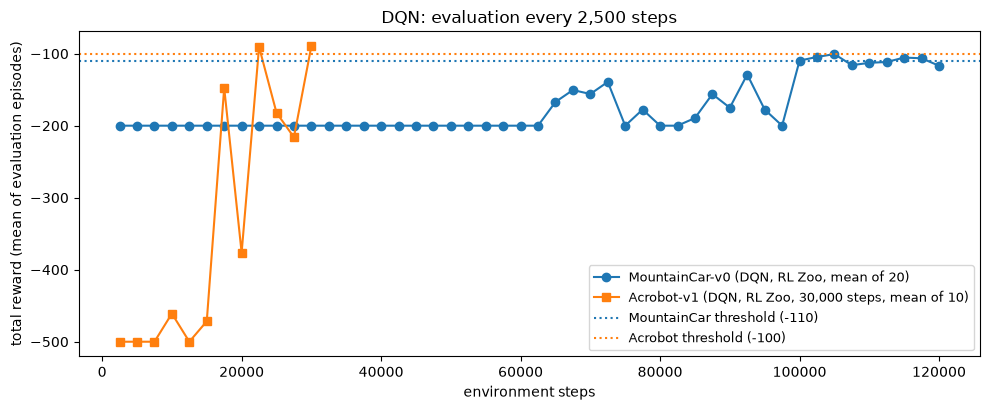

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(mc_callback.evaluations_timesteps, mc_evals, "o-", color="tab:blue", label="MountainCar-v0 (DQN, RL Zoo, mean of 20)")
ax.plot(ac_callback.evaluations_timesteps, ac_evals, "s-", color="tab:orange", label="Acrobot-v1 (DQN, RL Zoo, 30,000 steps, mean of 10)")
ax.axhline(-110, color="tab:blue", linestyle=":", label="MountainCar threshold (-110)")
ax.axhline(-100, color="tab:orange", linestyle=":", label="Acrobot threshold (-100)")
ax.set_xlabel("environment steps")
ax.set_ylabel("total reward (mean of evaluation episodes)")
ax.set_title("DQN: evaluation every 2,500 steps")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "ch09_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 青い丸が MountainCar（4節）、橙の四角が Acrobot（6-1節）の学習中の評価で、点線がそれぞれの「解けた」の目安（-110 と -100）です。青い丸は 62,500 ステップまで -200 の横一直線で、65,000 ステップから上がり始め、100,000 ステップ以降は -110 の点線の近くにいます。橙の四角は 15,000 ステップまで -500 の近くにいて、17,500 ステップで大きく上がり、22,500 ステップと 30,000 ステップでは -100 の点線の近くまで来ています。評価が初めて打ち切りの値（-200 と -500）から離れたのは、Acrobot が 10,000 ステップ（-460.9）、MountainCar が 65,000 ステップでした。

### 6-3. 振り上げる様子を見る

一番よい時点のモデルで1エピソード遊ばせ、2 ステップごとの絵を GIF に保存します。Acrobot の描画は 1 秒に 15 ステップ（`render_fps`）なので、1 枚を 133 ミリ秒で表示すると、ほぼその速さです。

ゴールまでのステップ数: 73


GIF の枚数: 38


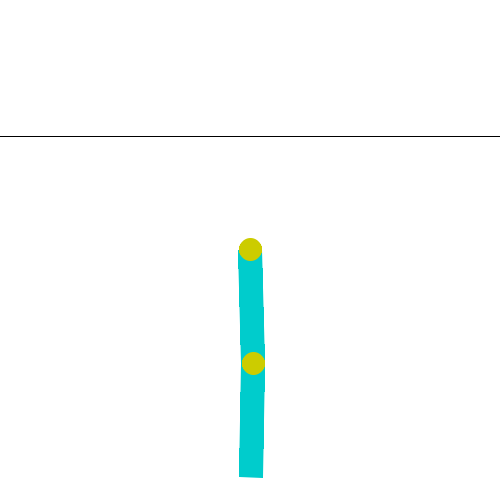

In [10]:
ac_shots = record_episode("Acrobot-v1", sb3_policy(ac_best), seed=0, every=2)
print("ゴールまでのステップ数:", ac_shots[-1][0])
imageio.v3.imwrite(FIGURES / "ch09_acrobot.gif", [frame for _, frame in ac_shots], duration=133, loop=0)
print("GIF の枚数:", len(ac_shots))
Image(filename=FIGURES / "ch09_acrobot.gif")

**期待する結果**（上の出力の読み方）: 一番よい時点のモデルは、`seed=0` で始めたこのエピソードで、73 ステップで先端が線を越えました。GIF には、最初の絵と 2 ステップごとの絵 36 枚と、線を越えたときの絵の、合わせて 38 枚を書き込みます。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、6-3節の GIF です。振り子は、はじめはまっすぐ下に垂れていて、関節を左右に回すたびに揺れが少しずつ大きくなり、最後に先端が上の灰色の線を越えます。

GitHub では、上の出力の GIF の動きは見られません。この GIF も、この章のフォルダの [README.md](README.md) で見られます。次のセルで、同じエピソードのコマ送りの図を作ります。

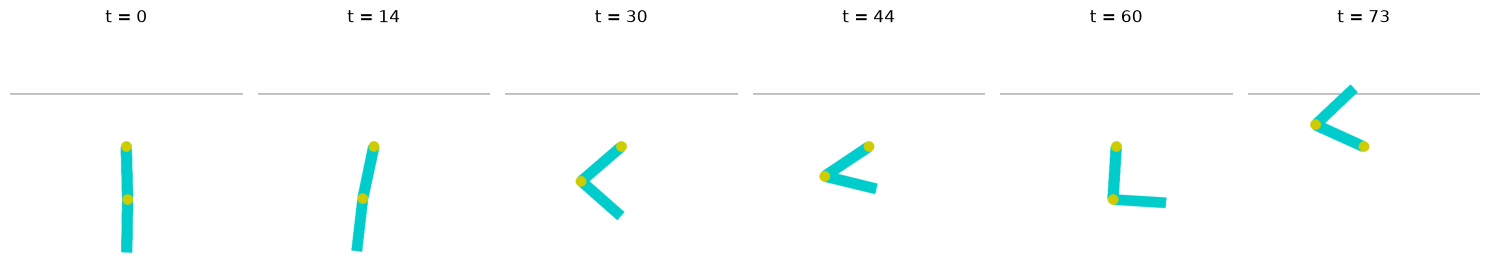

In [11]:
picks = np.linspace(0, len(ac_shots) - 1, 6).round().astype(int)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
for ax, i in zip(axes, picks):
    t, frame = ac_shots[i]
    ax.imshow(frame)
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "ch09_acrobot_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 6-3節のエピソードから、等間隔に選んだ 6 枚（t = 0、14、30、44、60、73）です。灰色の横線が、先端が越えるべき高さです。t = 0 ではまっすぐ下に垂れていた振り子が、t = 30〜60 では関節で大きく折れ曲がって横に振れ、t = 73 では先端が線より上にあります。

## 7. 遊んでみる

**やってみよう**:

- 3-2節のセルの `env.action_space.sample()` を `2`（いつも右へ加速）に変えてみてください。著者が試したところ、MountainCar では 100 回とも旗に着かず、台車が一番右まで行った位置は、100 回の中で一番右でも -0.153 でした
- 5-1節のセルの `shaping` の係数（100,000）を変えてみてください。著者が seed 0〜4 で試したところ、1,000 では初めて旗に着いたのが 430〜484 回目・旗に着いた回数が 32〜62 回、10,000 では 149〜217 回目・265〜301 回でした（100,000 では 4〜5 回目・759〜808 回。5-1節）
- 5-1節のセルの `N_BINS`（表の区切りの数）や `epsilon` を変えてみてください
- 4-1節の `MC_PARAMS` の値を1つずつ SB3 の既定値に戻して、どの値が効いているかを調べてみてください（著者は確かめていません。既定値は、導入した SB3 の `stable_baselines3/dqn/dqn.py` で見られます）
- 6-1節の `total_timesteps` を、RL Zoo のとおり 100,000 にしてみてください（著者の環境では 10 分を超えました）

## 8. まとめ

この章では、報酬がまれにしか得られない MountainCar と Acrobot を解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| でたらめな行動で、ゴールに着く回数を数える | `env.action_space.sample()` | 3節 |
| SB3 の DQN を RL Zoo の値で学習させ、MountainCar を解く | `DQN`、`EvalCallback` | 4節 |
| 表形式の Q 学習に報酬設計を加えて比べる | `q_learning(shaping=...)`、`potential()` | 5節 |
| SB3 の DQN で Acrobot を解く | `DQN`（学習のステップ数を減らした RL Zoo の値） | 6節 |

MountainCar と Acrobot は、ゴールに着くまで、どう動いても 1ステップごとに -1 の報酬しか得られない環境でした。でたらめな行動では、MountainCar の旗には 100 回のうち一度も着けず、どの行動がよかったかを報酬から区別できません。SB3 の DQN は、RL Zoo の調整済みの値では MountainCar を解けましたが、既定値のままでは、seed 0〜4 のどれでも、最後の時点のモデルは旗に着けませんでした。表形式の Q 学習では、ポテンシャルに基づく報酬設計を足すと、どの seed でも、初めて旗に着くまでのエピソードが 400 回以上から 5 回以下に減りました。報酬設計は、学習の手がかりを足す工夫で、目標（早く旗に着く）は変えずに使えます。

- 次に読むもの: 第10章 Pendulum（準備中）
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第10章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0・Stable-Baselines3 2.9.0 のソースと動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。表形式の Q 学習のサンプルのコードは著者が書いたものです。

- A. Y. Ng, D. Harada, S. Russell, "Policy invariance under reward transformations: Theory and application to reward shaping", *Proceedings of the 16th International Conference on Machine Learning (ICML)*, 1999（ポテンシャルに基づく報酬設計）
- RL Baselines3 Zoo, v2.9.0 の `hyperparams/dqn.yml`（MountainCar-v0 と Acrobot-v1 のハイパーパラメータ）: https://github.com/DLR-RM/rl-baselines3-zoo/blob/v2.9.0/hyperparams/dqn.yml
- Stable-Baselines3 のソース（v2.9.0。`stable_baselines3/dqn/dqn.py`・`stable_baselines3/dqn/policies.py` の既定値、`stable_baselines3/common/off_policy_algorithm.py` の評価と学習の順番）: https://github.com/DLR-RM/stable-baselines3/tree/v2.9.0/stable_baselines3
- Gymnasium 1.3.0 のソース（導入したパッケージの中の `gymnasium/envs/classic_control/mountain_car.py`・`acrobot.py` の環境の説明と運動の式、`gymnasium/envs/__init__.py` の `reward_threshold` と打ち切りのステップ数）

4節と6節の GIF とコマ送りの図の絵は、Gymnasium（MIT License）の MountainCar と Acrobot の描画処理が出力したものです。グラフは、著者が matplotlib で描いたものです。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。